Import libraries :

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans

Load And Inspect Structure and Data Types :

In [2]:
data = pd.read_excel("Processed_Flipdata.xlsx")

In [3]:
print(data.head())

   Unnamed: 0            Model        Colour  Memory  RAM  Battery_  \
0           0  Infinix SMART 7   Night Black      64    4      6000   
1           1  Infinix SMART 7    Azure Blue      64    4      6000   
2           2     MOTOROLA G32  Mineral Gray     128    8      5000   
3           3         POCO C50    Royal Blue      32    2      5000   
4           4  Infinix HOT 30i      Marigold     128    8      5000   

  Rear Camera Front Camera  AI Lens  Mobile Height  \
0        13MP          5MP        1          16.76   
1        13MP          5MP        1          16.76   
2        50MP         16MP        0          16.64   
3         8MP          5MP        0          16.56   
4        50MP          5MP        1          16.76   

                   Processor_  Prize  
0  Unisoc Spreadtrum SC9863A1   7299  
1  Unisoc Spreadtrum SC9863A1   7299  
2     Qualcomm Snapdragon 680  11999  
3          Mediatek Helio A22   5649  
4                         G37   8999  


In [4]:
data

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999
...,...,...,...,...,...,...,...,...,...,...,...,...
536,637,SAMSUNG Galaxy S23 5G,Cream,256,8,3900,50MP,12MP,0,15.49,Qualcomm Snapdragon 8 Gen 2,79999
537,638,LAVA Z21,Cyan,32,2,3100,5MP,2MP,0,12.70,Octa Core,5998
538,639,Tecno Spark 8T,Turquoise Cyan,64,4,5000,50MP,8MP,0,16.76,MediaTek Helio G35,9990
539,641,SAMSUNG Galaxy A54 5G,Awesome Lime,128,8,5000,50MP,32MP,0,16.26,"Exynos 1380, Octa Core",38999


In [5]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    object 
 11  Prize          541 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 50.8+ KB
None


In [6]:
print("Rows:", data.shape[0], "Columns:", data.shape[1])

Rows: 541 Columns: 12


In [7]:
print(data.describe(include='all'))

        Unnamed: 0     Model  Colour      Memory         RAM     Battery_  \
count   541.000000       541     541  541.000000  541.000000   541.000000   
unique         NaN       187     275         NaN         NaN          NaN   
top            NaN  vivo Y16  Yellow         NaN         NaN          NaN   
freq           NaN         9      12         NaN         NaN          NaN   
mean    289.711645       NaN     NaN  110.550832    5.397412  4871.587800   
std     182.359185       NaN     NaN   60.600694    1.984923   780.148862   
min       0.000000       NaN     NaN   16.000000    2.000000   800.000000   
25%     135.000000       NaN     NaN   64.000000    4.000000  5000.000000   
50%     273.000000       NaN     NaN  128.000000    6.000000  5000.000000   
75%     434.000000       NaN     NaN  128.000000    8.000000  5000.000000   
max     642.000000       NaN     NaN  256.000000    8.000000  7000.000000   

       Rear Camera Front Camera     AI Lens  Mobile Height  \
count        

DATA PROCSSING :

In [8]:
data = data.dropna()

In [9]:
# Convert camera columns to numeric:
data['Rear Camera'] = data['Rear Camera'].str.replace('MP','').astype(float)
data['Front Camera'] = data['Front Camera'].str.replace('MP','').astype(float)


In [10]:
numeric_cols = ['Memory','RAM','Battery_','Rear Camera','Front Camera','AI Lens','Mobile Height','Prize']
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

In [11]:
#One-hot encoding for categorical variables:
categorical_cols = ['Model','Colour','Processor_']
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)


In [12]:
def detect_outliers_iqr(data, feature):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    return outliers


In [13]:
ram_outliers = detect_outliers_iqr(data, 'RAM')
print("Outliers in RAM:\n", ram_outliers[['RAM','Prize']])


Outliers in RAM:
 Empty DataFrame
Columns: [RAM, Prize]
Index: []


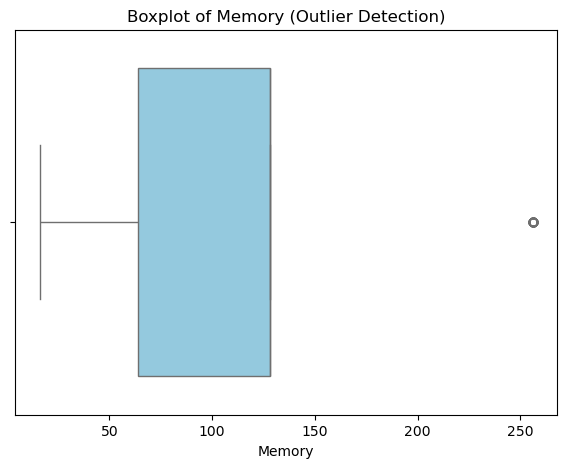

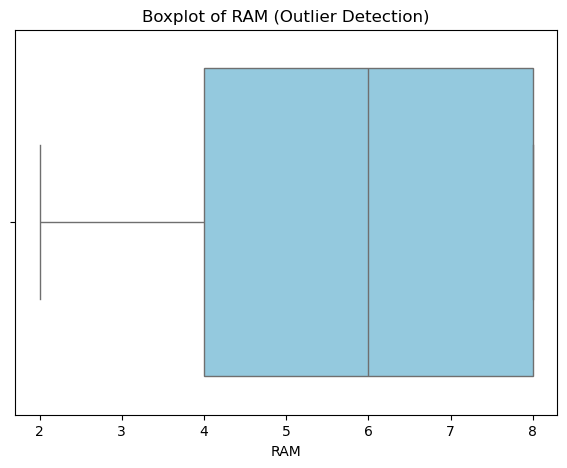

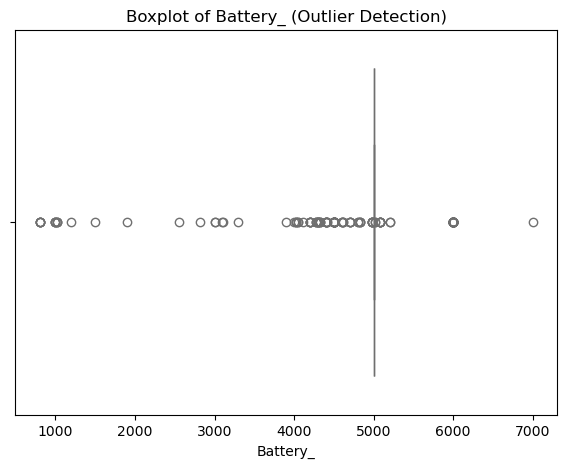

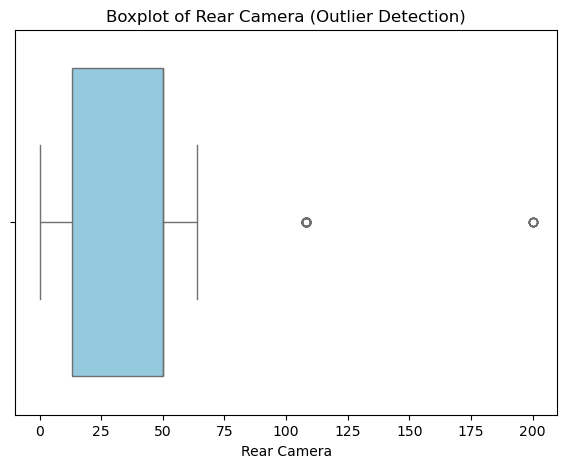

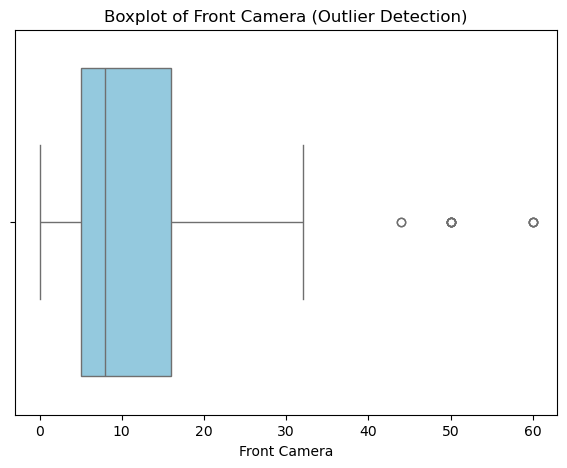

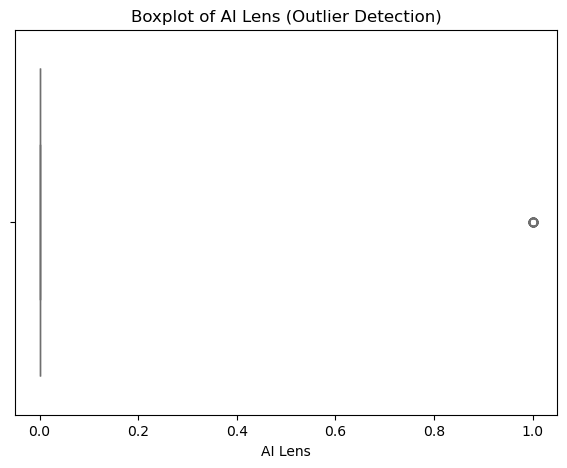

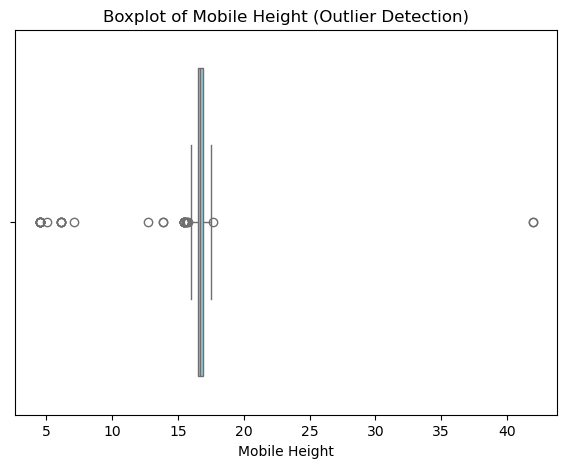

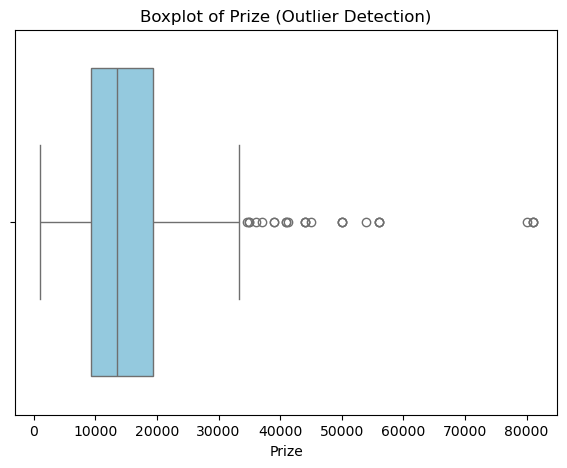

In [14]:
#Visualize Outliers with Boxplots
for feature in numeric_cols:
    plt.figure(figsize=(7,5))
    sns.boxplot(x=data[feature], color='skyblue')
    plt.title(f"Boxplot of {feature} (Outlier Detection)")
    plt.show()

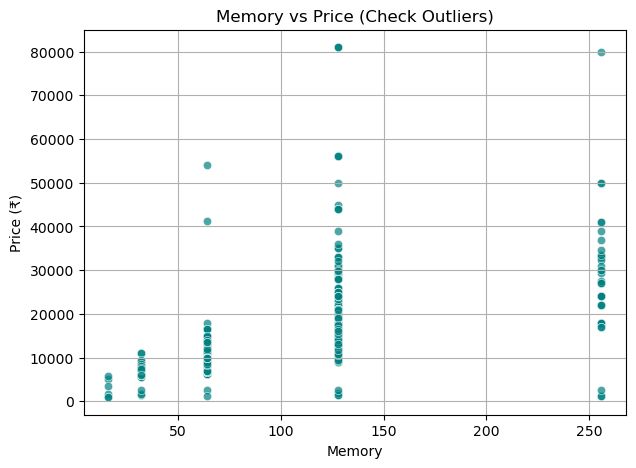

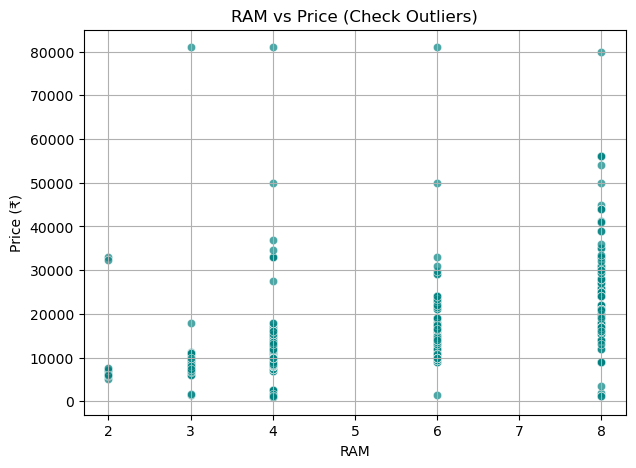

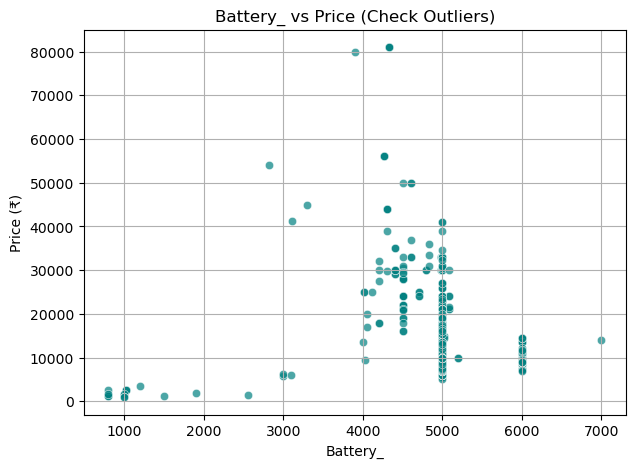

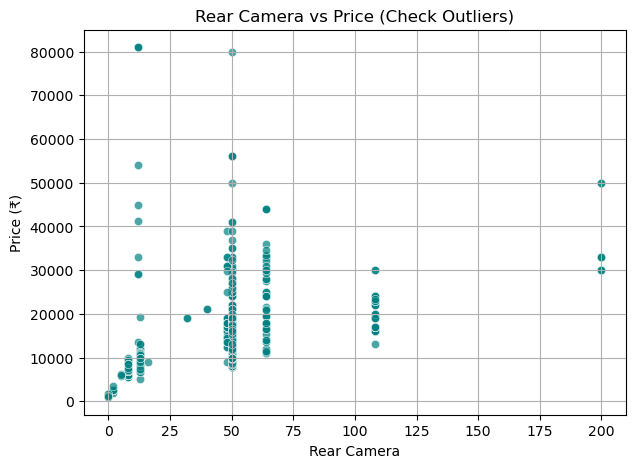

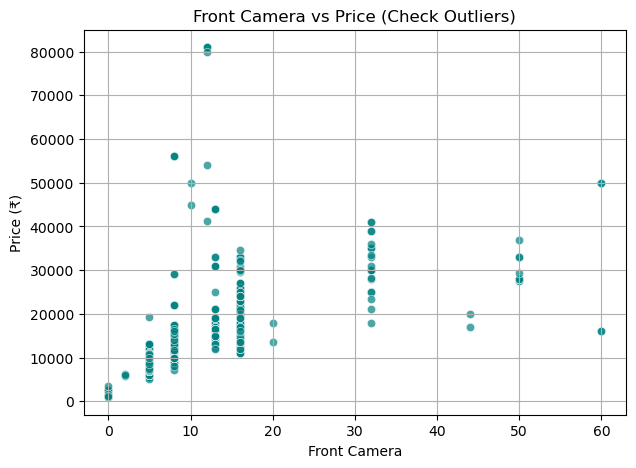

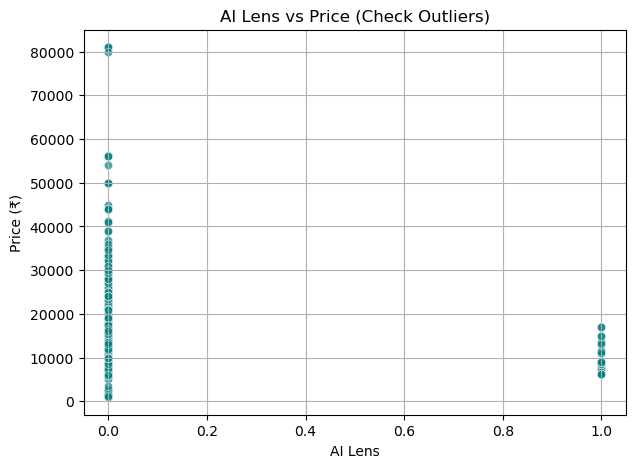

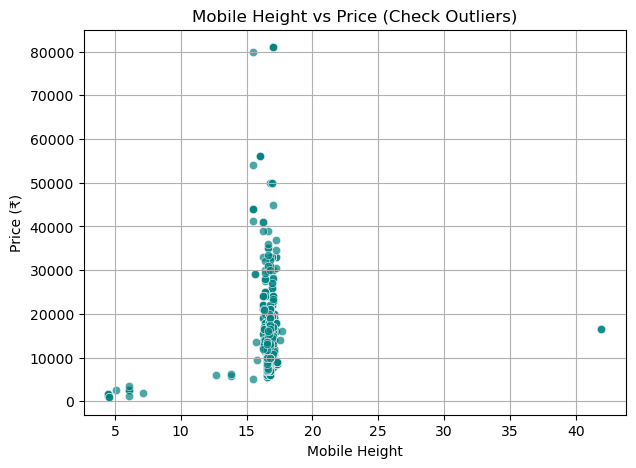

In [15]:
# Scatter plots vs Price to spot anomalies
for feature in numeric_cols:
    if feature != 'Prize':
        plt.figure(figsize=(7,5))
        sns.scatterplot(x=data[feature], y=data['Prize'], alpha=0.7, color='teal')
        plt.title(f"{feature} vs Price (Check Outliers)")
        plt.xlabel(feature)
        plt.ylabel("Price (₹)")
        plt.grid(True)
        plt.show()

In [16]:
print(data_encoded.shape)
print(data_encoded.head())
data_encoded

(541, 591)
   Unnamed: 0  Memory  RAM  Battery_  Rear Camera  Front Camera  AI Lens  \
0           0      64    4      6000         13.0           5.0        1   
1           1      64    4      6000         13.0           5.0        1   
2           2     128    8      5000         50.0          16.0        0   
3           3      32    2      5000          8.0           5.0        0   
4           4     128    8      5000         50.0           5.0        1   

   Mobile Height  Prize  Model_APPLE iPhone 12  ...  \
0          16.76   7299                  False  ...   
1          16.76   7299                  False  ...   
2          16.64  11999                  False  ...   
3          16.56   5649                  False  ...   
4          16.76   8999                  False  ...   

   Processor__Unisoc Spreadtrum SC9863A1  Processor__Unisoc T606  \
0                                   True                   False   
1                                   True                   False 

,Unnamed: 0,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Prize,Model_APPLE iPhone 12,...,Processor__Unisoc Spreadtrum SC9863A1,Processor__Unisoc T606,Processor__Unisoc T610,Processor__Unisoc T612,Processor__Unisoc T612 processor,Processor__Unisoc T616,Processor__Unisoc Tiger T612 (12 nm),Processor__Unisoc Tiger T616,Processor__ios,Processor__snapdragon 888
0,0,64,4,6000,13.0,5.0,1,16.76,7299,False,...,True,False,False,False,False,False,False,False,False,False
1,1,64,4,6000,13.0,5.0,1,16.76,7299,False,...,True,False,False,False,False,False,False,False,False,False
2,2,128,8,5000,50.0,16.0,0,16.64,11999,False,...,False,False,False,False,False,False,False,False,False,False
3,3,32,2,5000,8.0,5.0,0,16.56,5649,False,...,False,False,False,False,False,False,False,False,False,False
4,4,128,8,5000,50.0,5.0,1,16.76,8999,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,637,256,8,3900,50.0,12.0,0,15.49,79999,False,...,False,False,False,False,False,False,False,False,False,False
537,638,32,2,3100,5.0,2.0,0,12.70,5998,False,...,False,False,False,False,False,False,False,False,False,False
538,639,64,4,5000,50.0,8.0,0,16.76,9990,False,...,False,False,False,False,False,False,False,False,False,False
539,641,128,8,5000,50.0,32.0,0,16.26,38999,False,...,False,False,False,False,False,False,False,False,False,False


Feature Extraction:

In [17]:
X = data_encoded.drop('Prize', axis=1)
y = data_encoded['Prize']

In [18]:
# Train Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X, y)


RandomForestRegressor(n_estimators=200, random_state=42)

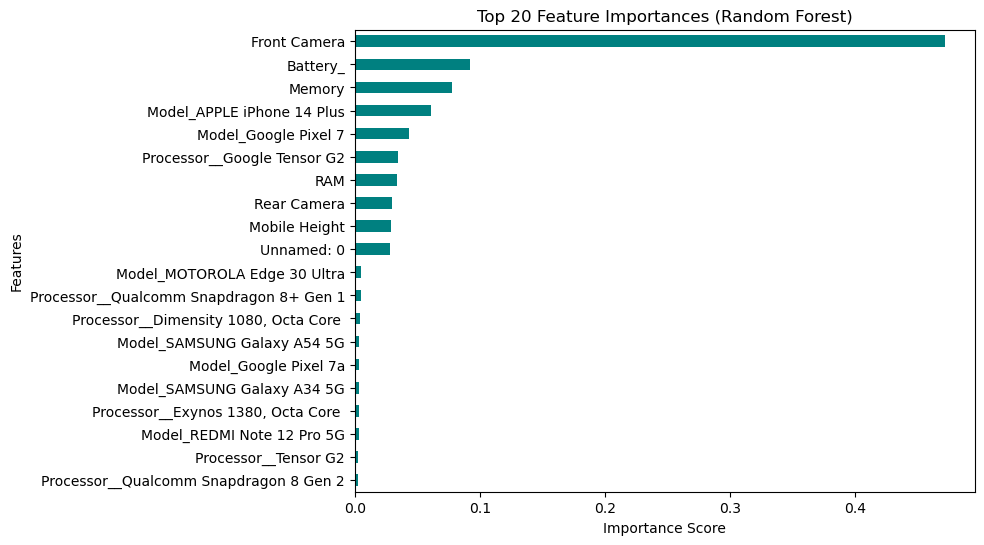

In [19]:
# Feature Visualization
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(8,6))
top_features.plot(kind='barh', color='teal')
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

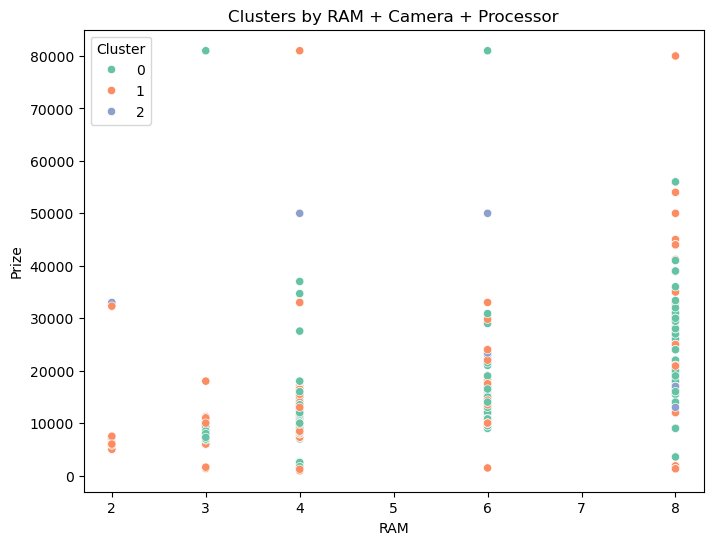

In [20]:
# Clustering by RAM + Processor + Camera
le = LabelEncoder()
data['Processor_encoded'] = le.fit_transform(data['Processor_'])

cluster_data = data[['RAM','Rear Camera','Processor_encoded']]
kmeans = KMeans(n_clusters=3, random_state=42)
data['Cluster'] = kmeans.fit_predict(cluster_data)

plt.figure(figsize=(8,6))
sns.scatterplot(x=data['RAM'], y=data['Prize'], hue=data['Cluster'], palette='Set2')
plt.title("Clusters by RAM + Camera + Processor")
plt.show()


In [21]:
def simulate_price_change(phone_idx, add_ram=0, upgrade_processor=None):
    phone = X.iloc[phone_idx].copy()
    # Add RAM
    if add_ram > 0:
        phone['RAM'] += add_ram
    # Upgrade processor (set one-hot encoding)
    if upgrade_processor:
        for col in X.columns:
            if col.startswith("Processor_"):
                phone[col] = 0
        if f"Processor_{upgrade_processor}" in X.columns:
            phone[f"Processor_{upgrade_processor}"] = 1
    predicted_price = rf.predict([phone])[0]
    return predicted_price


In [22]:
# Example: simulate adding 2GB RAM to phone at index 0
print("Original Price:", y.iloc[0])
print("Predicted Price after +2GB RAM:", simulate_price_change(0, add_ram=2))

Original Price: 7299
Predicted Price after +2GB RAM: 7525.455


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [23]:
# Example: simulate upgrading processor to Snapdragon 680
print("Predicted Price after processor upgrade:", simulate_price_change(0, upgrade_processor="Qualcomm Snapdragon 680"))

Predicted Price after processor upgrade: 7313.35


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [24]:
# Pricing Tool Function
def recommend_price(phone_specs):
    # phone_specs should be a dict with keys matching X columns
    phone_vector = pd.DataFrame([phone_specs], columns=X.columns)
    return rf.predict(phone_vector)[0]


In [25]:
example_phone = X.iloc[10].to_dict()
predicted_price = recommend_price(example_phone)
print("Recommended Launch Price:", predicted_price)

Recommended Launch Price: 9056.5


Model Building:

In [26]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# Train Model Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [28]:
# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [29]:
# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [30]:
# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)


In [31]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.3f}")

In [32]:
# Evaluate all models
evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("Gradient Boosting", y_test, y_pred_gb)

Linear Regression -> MAE: 2092.98, RMSE: 6156.99, R²: 0.725
Decision Tree -> MAE: 1683.61, RMSE: 4699.82, R²: 0.840
Random Forest -> MAE: 1875.22, RMSE: 4731.66, R²: 0.838
Gradient Boosting -> MAE: 1893.08, RMSE: 4726.15, R²: 0.838


Feature Importance Analysis:

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)


RandomForestRegressor(n_estimators=200, random_state=42)

In [34]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(20)

print("Top 20 Features Influencing Price:")
print(top_features)

Top 20 Features Influencing Price:
Front Camera                             0.408063
Battery_                                 0.087262
Memory                                   0.083531
Model_APPLE iPhone 14 Plus               0.059619
RAM                                      0.055750
Model_Google Pixel 7                     0.049554
Processor__Google Tensor G2              0.044255
Mobile Height                            0.037579
Rear Camera                              0.030207
Unnamed: 0                               0.030057
Colour_Purple                            0.007984
Processor__Dimensity 1080, Octa Core     0.004858
Model_SAMSUNG Galaxy A34 5G              0.004775
Processor__Google Tensor                 0.003718
Model_SAMSUNG Galaxy A54 5G              0.003636
Processor__Tensor G2                     0.003402
Colour_Midnight                          0.003274
Model_Google Pixel 6a                    0.003181
Colour_Snow                              0.002936
Model_REDMI Not

VISUALIZATIONS :

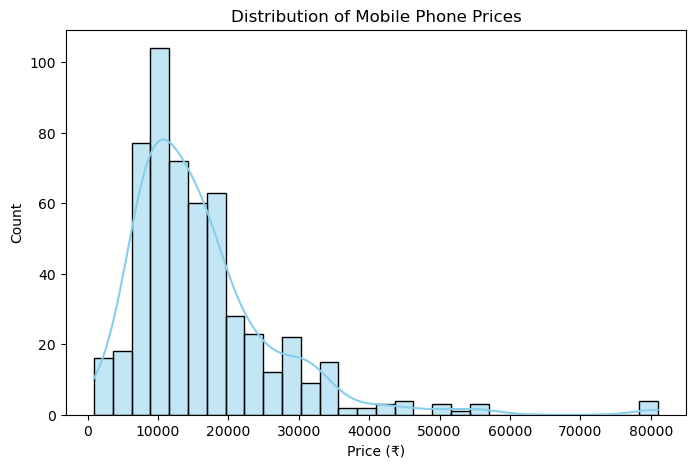

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(y, bins=30, kde=True, color="skyblue")
plt.title("Distribution of Mobile Phone Prices")
plt.xlabel("Price (₹)")
plt.ylabel("Count")
plt.show()

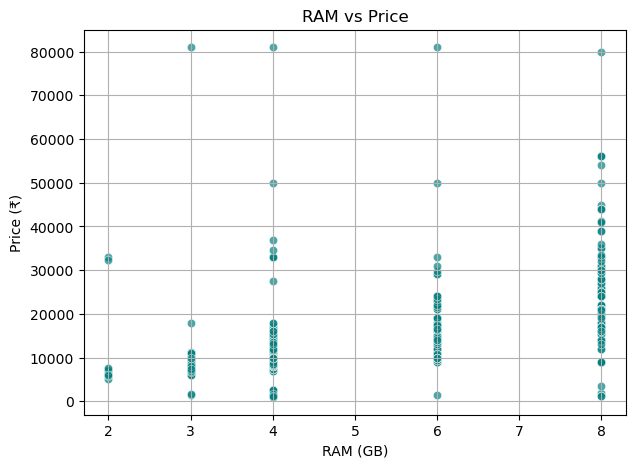

In [36]:
# RAM vs Price
plt.figure(figsize=(7,5))
sns.scatterplot(x=data_encoded['RAM'], y=data_encoded['Prize'], alpha=0.7, color='teal')
plt.title("RAM vs Price")
plt.xlabel("RAM (GB)")
plt.ylabel("Price (₹)")
plt.grid(True)
plt.show()

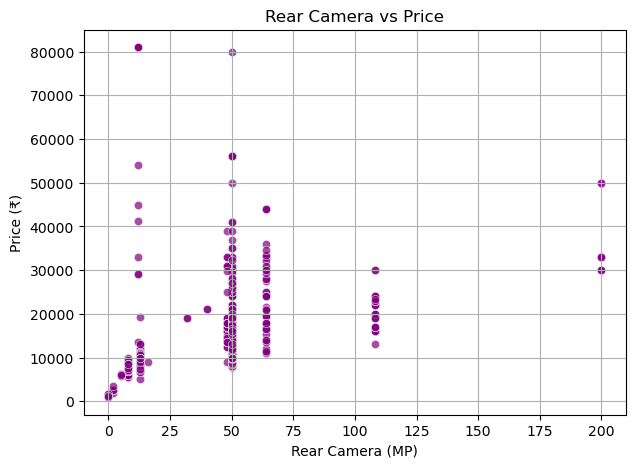

In [37]:
# Rear Camera vs Price
plt.figure(figsize=(7,5))
sns.scatterplot(x=data_encoded['Rear Camera'], y=data_encoded['Prize'], alpha=0.7, color='purple')
plt.title("Rear Camera vs Price")
plt.xlabel("Rear Camera (MP)")
plt.ylabel("Price (₹)")
plt.grid(True)
plt.show()

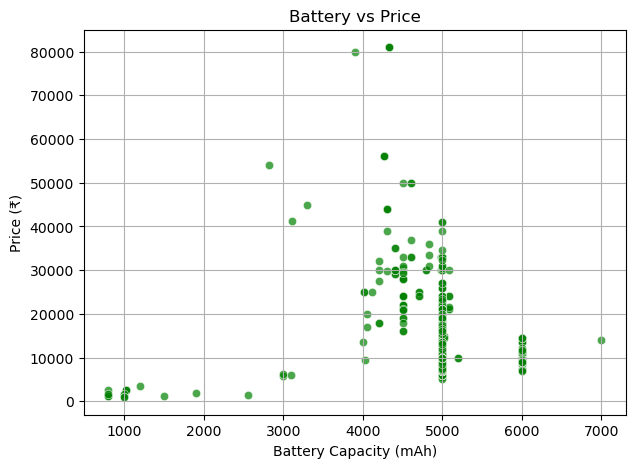

In [38]:
# Battery vs Price
plt.figure(figsize=(7,5))
sns.scatterplot(x=data_encoded['Battery_'], y=data_encoded['Prize'], alpha=0.7, color='green')
plt.title("Battery vs Price")
plt.xlabel("Battery Capacity (mAh)")
plt.ylabel("Price (₹)")
plt.grid(True)
plt.show()

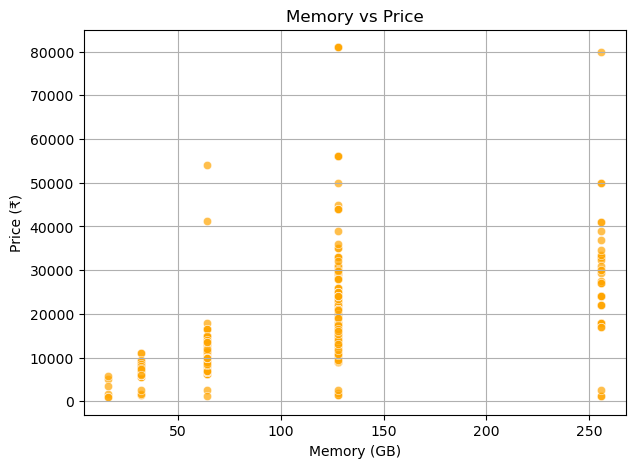

In [39]:
# Memory vs Price
plt.figure(figsize=(7,5))
sns.scatterplot(x=data_encoded['Memory'], y=data_encoded['Prize'], alpha=0.7, color='orange')
plt.title("Memory vs Price")
plt.xlabel("Memory (GB)")
plt.ylabel("Price (₹)")
plt.grid(True)
plt.show()

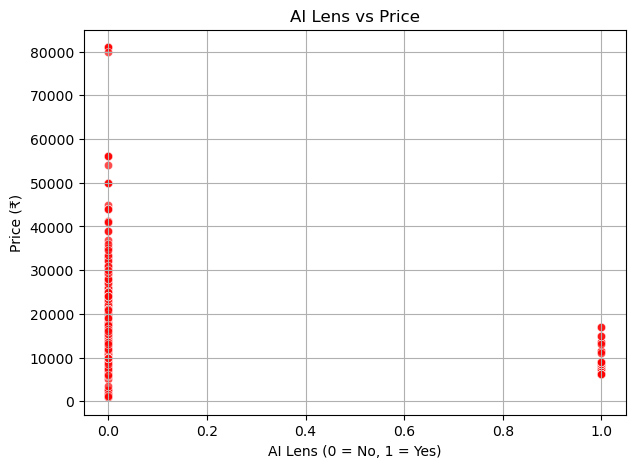

In [40]:
# AI Lens vs Price
plt.figure(figsize=(7,5))
sns.scatterplot(x=data_encoded['AI Lens'], y=data_encoded['Prize'], alpha=0.7, color='red')
plt.title("AI Lens vs Price")
plt.xlabel("AI Lens (0 = No, 1 = Yes)")
plt.ylabel("Price (₹)")
plt.grid(True)
plt.show()

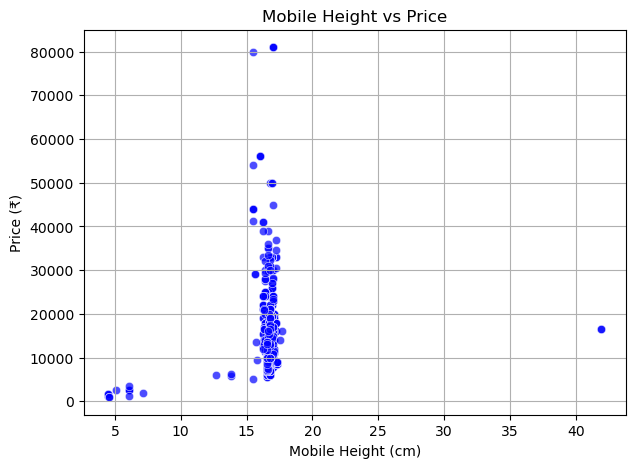

In [41]:
# Mobile Height vs Price
plt.figure(figsize=(7,5))
sns.scatterplot(x=data_encoded['Mobile Height'], y=data_encoded['Prize'], alpha=0.7, color='blue')
plt.title("Mobile Height vs Price")
plt.xlabel("Mobile Height (cm)")
plt.ylabel("Price (₹)")
plt.grid(True)
plt.show()
